2nd_Project

# 1.환경준비

## 1.1. 라이브러리 불러오기

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic
import scipy.stats as spst

## 1.2. 데이터 로딩

In [3]:
# 직원 이직 데이터
path = 'prep_hotel_bookings.csv'
df = pd.read_csv(path)
df.head()

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,reservation_date,diff_reserved_room_type
0,Resort Hotel,0,342,0,0,2,0.0,0,BB,PRT,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2014-07-24,False
1,Resort Hotel,0,737,0,0,2,0.0,0,BB,PRT,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2013-06-24,False
2,Resort Hotel,0,7,0,1,1,0.0,0,BB,GBR,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,2015-06-24,True
3,Resort Hotel,0,13,0,1,1,0.0,0,BB,GBR,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,2015-06-18,False
4,Resort Hotel,0,14,0,2,2,0.0,0,BB,GBR,...,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2015-06-17,False


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118902 entries, 0 to 118901
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118902 non-null  str    
 1   is_canceled                     118902 non-null  int64  
 2   lead_time                       118902 non-null  int64  
 3   stays_in_weekend_nights         118902 non-null  int64  
 4   stays_in_week_nights            118902 non-null  int64  
 5   adults                          118902 non-null  int64  
 6   children                        118902 non-null  float64
 7   babies                          118902 non-null  int64  
 8   meal                            118902 non-null  str    
 9   country                         118902 non-null  str    
 10  market_segment                  118902 non-null  str    
 11  distribution_channel            118902 non-null  str    
 12  is_repeated_guest          

In [5]:
df.describe()

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000,118902.000000
mean,0.371373,104.308027,0.928891,2.502136,1.858404,0.104203,0.007948,0.032010,0.087139,0.131629,0.221174,74.893938,10.562354,2.330676,102.000808,0.061883,0.571706
std,0.483174,106.903127,0.996211,1.900165,0.578576,0.399166,0.097379,0.176026,0.845855,1.484647,0.652775,107.144715,53.512305,17.630161,50.487004,0.244168,0.792678
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,70.000000,0.000000,0.000000
50%,0.000000,69.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,95.000000,0.000000,0.000000
75%,1.000000,161.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,152.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


C:\Users\playdata2\AppData\Local\Temp\ipykernel_2360\114796040.py:42: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_2360\114796040.py:42: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_2360\114796040.py:42: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_2360\114796040.py:42: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_2360\114796040.py:42: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_2360\114796040.py:42: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO})

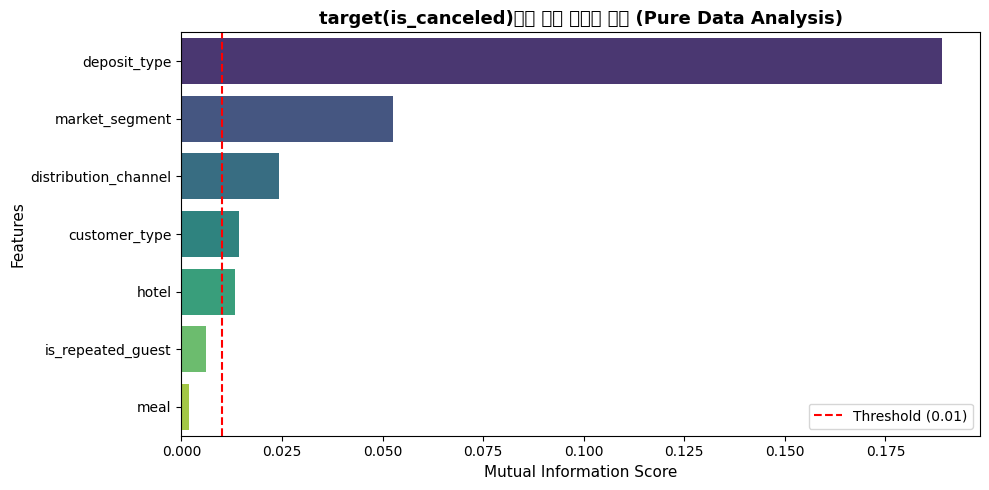

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def entropy(probs):
    return -np.sum(probs * np.log2(probs + 1e-12))

def calculate_mutual_information(df, col, target):

    p_x = df[col].value_counts(normalize=True).values
    p_y = df[target].value_counts(normalize=True).values
    
    p_xy = df.groupby([col, target]).size() / len(df)
    p_xy = p_xy.values
    
    H_x = entropy(p_x)
    H_y = entropy(p_y)
    H_xy = entropy(p_xy)
    
    mi = H_x + H_y - H_xy
    return max(0.0, mi)

cols_to_analyze = [
    'deposit_type', 'hotel', 'meal', 'market_segment', 
    'distribution_channel', 'customer_type', 'is_repeated_guest'
]

mi_scores = {}
for col in cols_to_analyze:
    mi_scores[col] = calculate_mutual_information(df, col, 'is_canceled')

mi_series = pd.Series(mi_scores).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis", hue=mi_series.index, legend=False)
plt.axvline(x=0.01, color='red', linestyle='--', label='Threshold (0.01)')
plt.title("target(is_canceled)과의 상호 정보량 랭킹 (Pure Data Analysis)", fontsize=13, fontweight='bold')
plt.xlabel("Mutual Information Score", fontsize=11)
plt.ylabel("Features", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

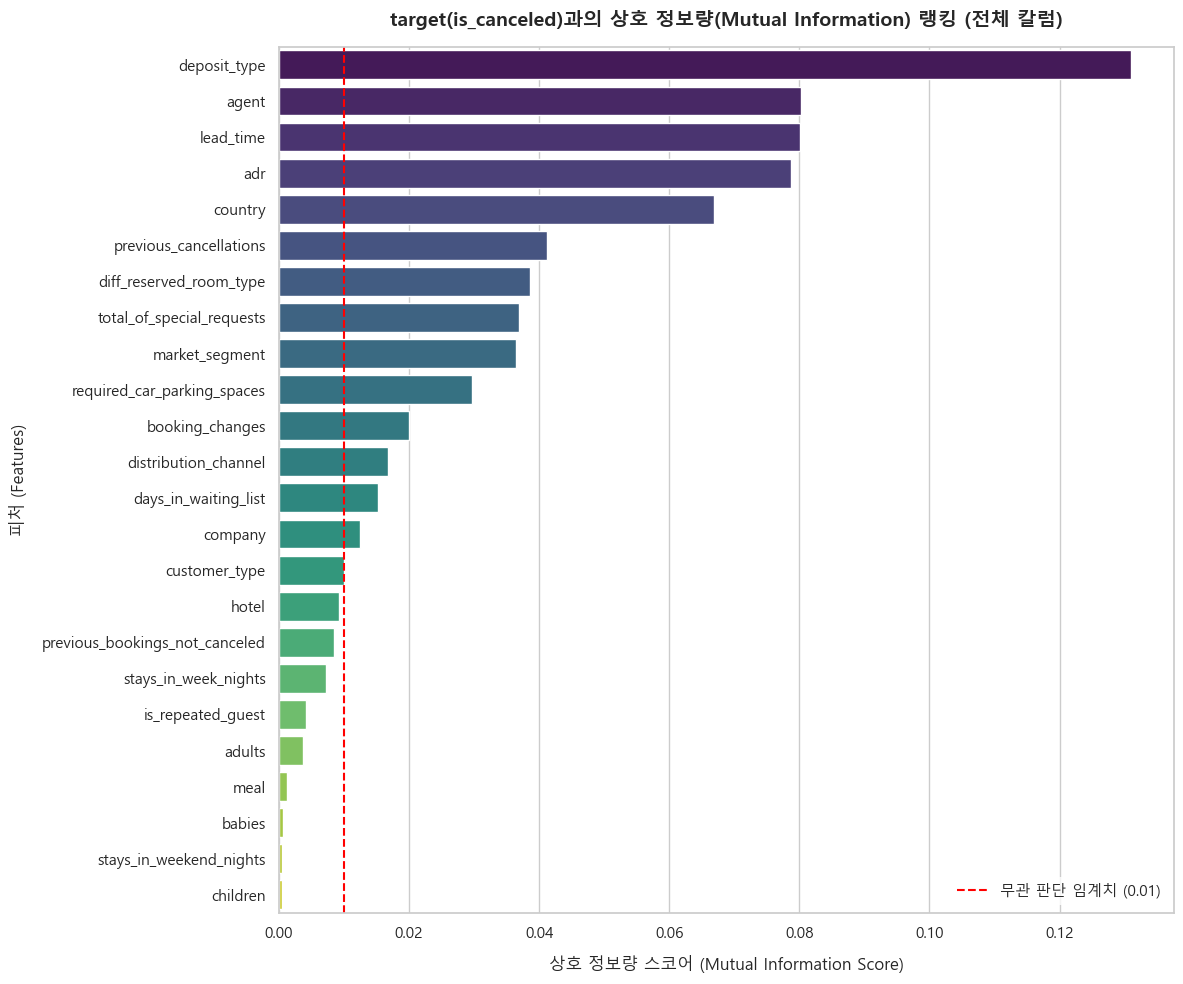

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from pandas.api.types import is_numeric_dtype

df = pd.read_csv('prep_hotel_bookings.csv')

exclude_cols = ['is_canceled', 'reservation_status', 'reservation_status_date', 'arrival_date', 'reservation_date']
features = [col for col in df.columns if col not in exclude_cols]

X = df[features].copy()
y = df['is_canceled']

discrete_features = []
for col in features:
    if not is_numeric_dtype(X[col]) or X[col].dtype == 'bool':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        discrete_features.append(True)
    else:
        if col in ['lead_time', 'adr']:
            discrete_features.append(False)
        else:
            discrete_features.append(True)

mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features, random_state=42)

mi_df = pd.DataFrame({
    'Feature': features,
    'Mutual_Information': mi_scores
}).sort_values(by='Mutual_Information', ascending=False)

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False    
plt.rcParams['figure.dpi'] = 150

sns.barplot(
    x='Mutual_Information', 
    y='Feature', 
    data=mi_df, 
    palette="viridis", 
    hue='Feature', 
    legend=False
)

plt.axvline(x=0.01, color='red', linestyle='--', linewidth=1.5, label='무관 판단 임계치 (0.01)')

plt.title("target(is_canceled)과의 상호 정보량(Mutual Information) 랭킹 (전체 칼럼)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("상호 정보량 스코어 (Mutual Information Score)", fontsize=12, labelpad=10)
plt.ylabel("피처 (Features)", fontsize=12, labelpad=10)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()


In [8]:
target = 'is_canceled'

### 1. lead_time

In [9]:
df['is_canceled'].mean()

np.float64(0.3713730635313115)

1) 교차표

In [10]:
feature = 'lead_time'

In [11]:
pd.crosstab(df[target], df[feature])

lead_time,0,1,2,3,4,5,6,7,8,9,...,594,601,605,608,615,622,626,629,709,737
is_canceled,,,,,,,,,,,,,,,,,,,,,
0,5807,3076,1823,1621,1523,1339,1220,1138,903,766,...,0,0,0,0,0,0,0,0,1,1
1,416,319,211,181,173,206,202,172,222,219,...,17,17,30,17,17,17,30,17,0,0


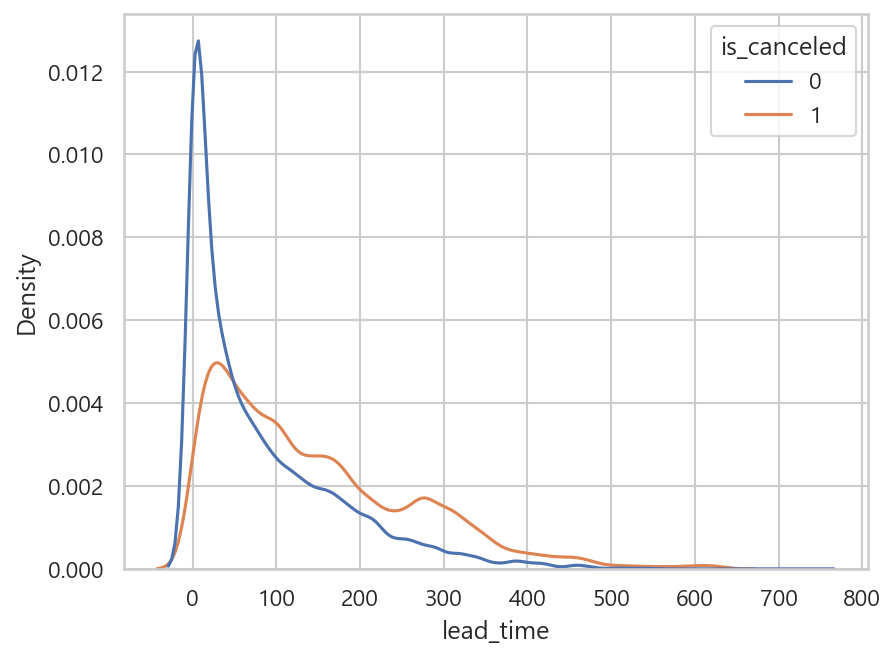

In [12]:
sns.kdeplot(x= feature,
            data = df,
            hue = target,
            common_norm = False)
plt.show()

C:\Users\playdata2\AppData\Local\Temp\ipykernel_22764\223057284.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='예약 상태', loc='upper right', frameon=True, facecolor='white', edgecolor='none')


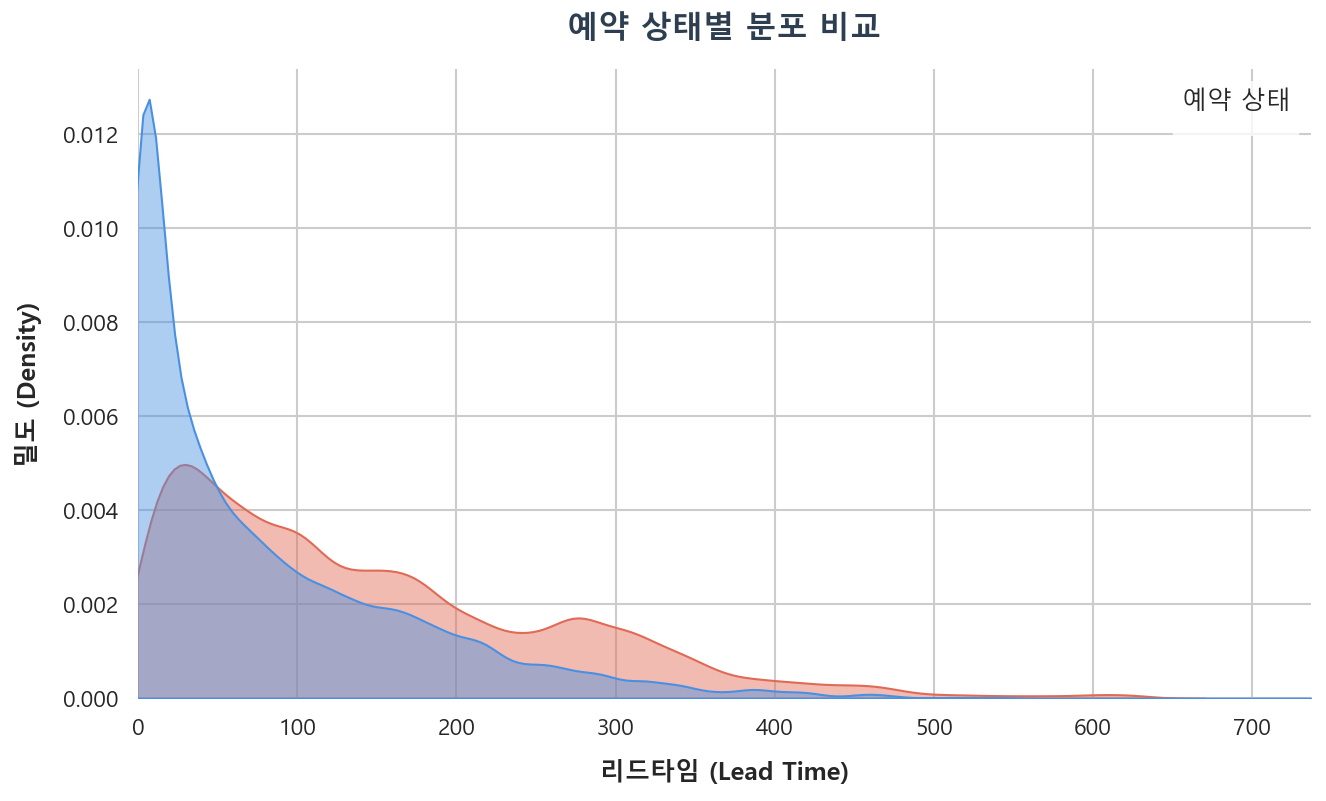

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

var = 'lead_time'
var_name_kor = '리드타임 (Lead Time)'

def plot_kde_density(var, data, target='is_canceled', var_name_kor=None):
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    sns.set_theme(style="whitegrid", font="Malgun Gothic")
    
    plot_df = data[[var, target]].copy()
    plot_df['예약 상태'] = plot_df[target].map({0: '정상 투숙 (0)', 1: '취소 (1)'})
    
    plt.figure(figsize=(9, 5.5))
    x_min = int(data[var].min())
    x_max = int(data[var].max())
    
    custom_colors = {'정상 투숙 (0)': '#4A90E2', '취소 (1)': '#E06A55'}
    
    sns.kdeplot(
        x=var,
        data=plot_df,
        hue='예약 상태',
        common_norm=False,
        palette=custom_colors,
        alpha=0.45,
        fill=True
    )
    
    plt.xlim(x_min, x_max)
    
    xlabel = var_name_kor if var_name_kor else var
    plt.title('예약 상태별 분포 비교', fontsize=15, fontweight='bold', pad=15, color='#2C3E50')
    plt.xlabel(xlabel, fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('밀도 (Density)', fontsize=12, fontweight='bold', labelpad=10)
    
    plt.legend(title='예약 상태', loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

plot_kde_density(var, df, var_name_kor=var_name_kor)


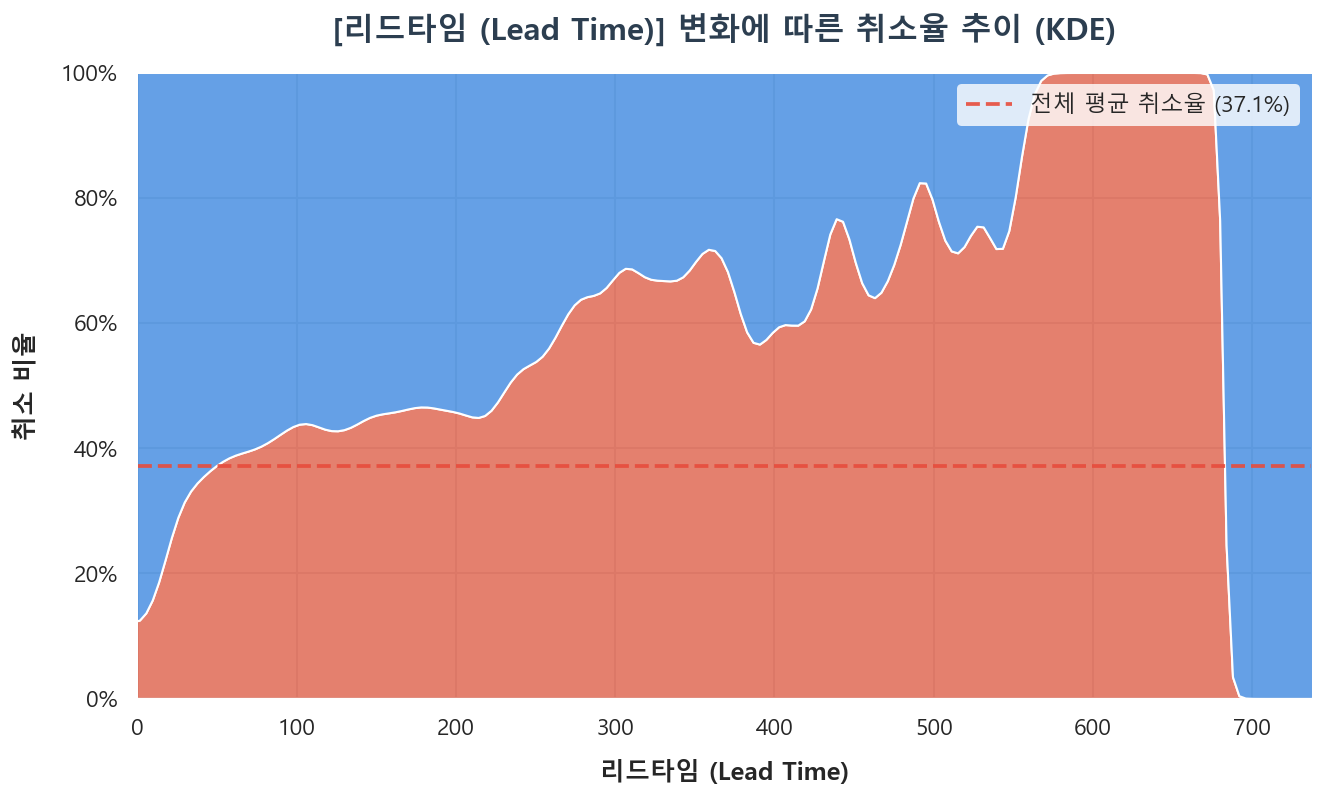

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import pandas as pd

var = 'lead_time'
var_name_kor = '리드타임 (Lead Time)'

# 1. 시각화 함수 정의
def plot_kde_ratio(var, data, target='is_canceled', var_name_kor=None):
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    sns.set_theme(style="whitegrid", font="Malgun Gothic")
    
    plot_df = data[[var, target]].copy()
    plot_df['예약 상태'] = plot_df[target].map({0: '정상 투숙 (0)', 1: '취소 (1)'})
    
    plt.figure(figsize=(9, 5.5))
    x_min = int(data[var].min())
    x_max = int(data[var].max())
    
    custom_colors = {'정상 투숙 (0)': '#4A90E2', '취소 (1)': '#E06A55'}
    
    sns.kdeplot(
        x=var,
        data=plot_df,
        hue='예약 상태',
        multiple='fill',
        palette=custom_colors,
        alpha=0.85
    )
    
    total_mean = data[target].mean()
    plt.axhline(
        total_mean, 
        color='#E74C3C', 
        linestyle='--', 
        linewidth=1.8, 
        alpha=0.9,
        label=f'전체 평균 취소율 ({total_mean:.1%})'
    )
    
    plt.xlim(x_min, x_max)
    plt.ylim(0, 1)
    
    plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    
    xlabel = var_name_kor if var_name_kor else var
    plt.title(f'[{xlabel}] 변화에 따른 취소율 추이 (KDE)', fontsize=15, fontweight='bold', pad=15, color='#2C3E50')
    plt.xlabel(xlabel, fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('취소 비율', fontsize=12, fontweight='bold', labelpad=10)
    
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

plot_kde_ratio(var, df, var_name_kor=var_name_kor)


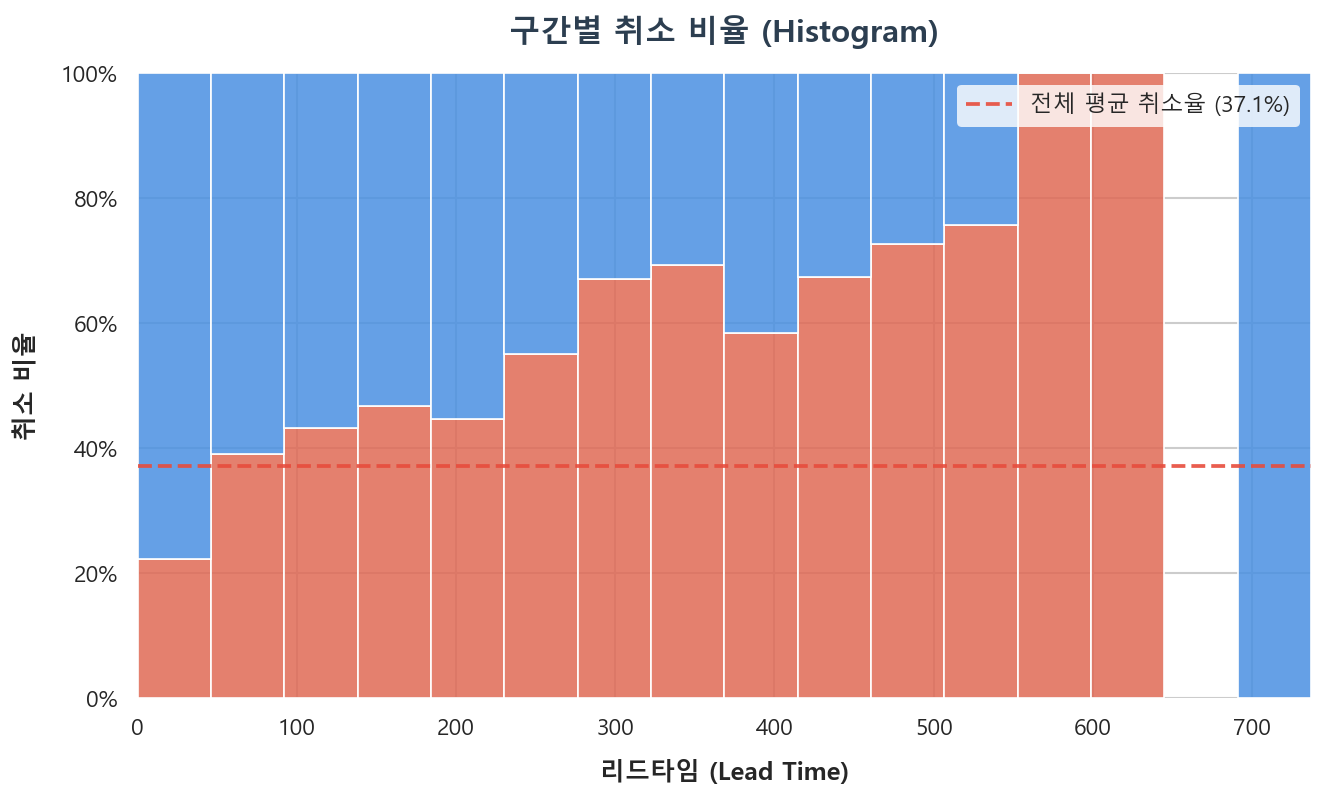

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import pandas as pd

var = 'lead_time'
var_name_kor = '리드타임 (Lead Time)'
bins_count = 16 # 히스토그램의 구간 개수 설정

# 1. 시각화 함수 정의
def plot_hist_ratio(var, data, bins=16, target='is_canceled', var_name_kor=None):
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    sns.set_theme(style="whitegrid", font="Malgun Gothic")
    
    plot_df = data[[var, target]].copy()
    plot_df['예약 상태'] = plot_df[target].map({0: '정상 투숙 (0)', 1: '취소 (1)'})
    
    plt.figure(figsize=(9, 5.5))
    x_min = int(data[var].min())
    x_max = int(data[var].max())
    
    custom_colors = {'정상 투숙 (0)': '#4A90E2', '취소 (1)': '#E06A55'}
    
    sns.histplot(
        x=var,
        data=plot_df,
        bins=bins,
        hue='예약 상태',
        multiple='fill',
        palette=custom_colors,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.8
    )
    
    total_mean = data[target].mean()
    plt.axhline(
        total_mean, 
        color='#E74C3C', 
        linestyle='--', 
        linewidth=1.8, 
        alpha=0.9,
        label=f'전체 평균 취소율 ({total_mean:.1%})'
    )
    
    plt.xlim(x_min, x_max)
    plt.ylim(0, 1)
    
    plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    
    xlabel = var_name_kor if var_name_kor else var
    plt.title('구간별 취소 비율 (Histogram)', fontsize=15, fontweight='bold', pad=15, color='#2C3E50')
    plt.xlabel(xlabel, fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('취소 비율', fontsize=12, fontweight='bold', labelpad=10)
    
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

plot_hist_ratio(var, df, bins=bins_count, var_name_kor=var_name_kor)


In [ ]:
import scipy.stats as spst
import pandas as pd

t_stat, t_p = spst.ttest_ind(
    df.loc[df['is_canceled'] == 1, 'lead_time'], 
    df.loc[df['is_canceled'] == 0, 'lead_time'], 
    equal_var=False
)

print(f"t-통계량: {t_stat:.2f}")
print(f"p-value : {t_p:.4f}")
print("-" * 50)

# 2. 4개 구간 분할 카이제곱 검정
bins = [-1, 30, 90, 180, 9999]
labels = ['1개월 미만', '1-3개월', '3-6개월', '6개월 이상']
df['lead_time_group'] = pd.cut(df['lead_time'], bins=bins, labels=labels)
table = pd.crosstab(df['is_canceled'], df['lead_time_group'])

chi2, p, dof, expected = spst.chi2_contingency(table)
print("=== 카이제곱 검정 (4개 구간 분할) ===")
print("교차표:\n", table)
print(f"카이제곱통계량: {chi2:.2f}")
print(f"p-value : {p:.4f}")
print(f"자유도  : {dof}")


=== 독립표본 T-검정 ===
t-통계량: 98.50
p-value : 0.0000
--------------------------------------------------
=== 카이제곱 검정 (4개 구간 분할) ===
교차표:
 lead_time_group  1개월 미만  1-3개월  3-6개월  6개월 이상
is_canceled                                  
0                 31162  18384  14593   10606
1                  7155  11132  11820   14050
카이제곱통계량: 10415.67
p-value : 0.0000
자유도  : 3


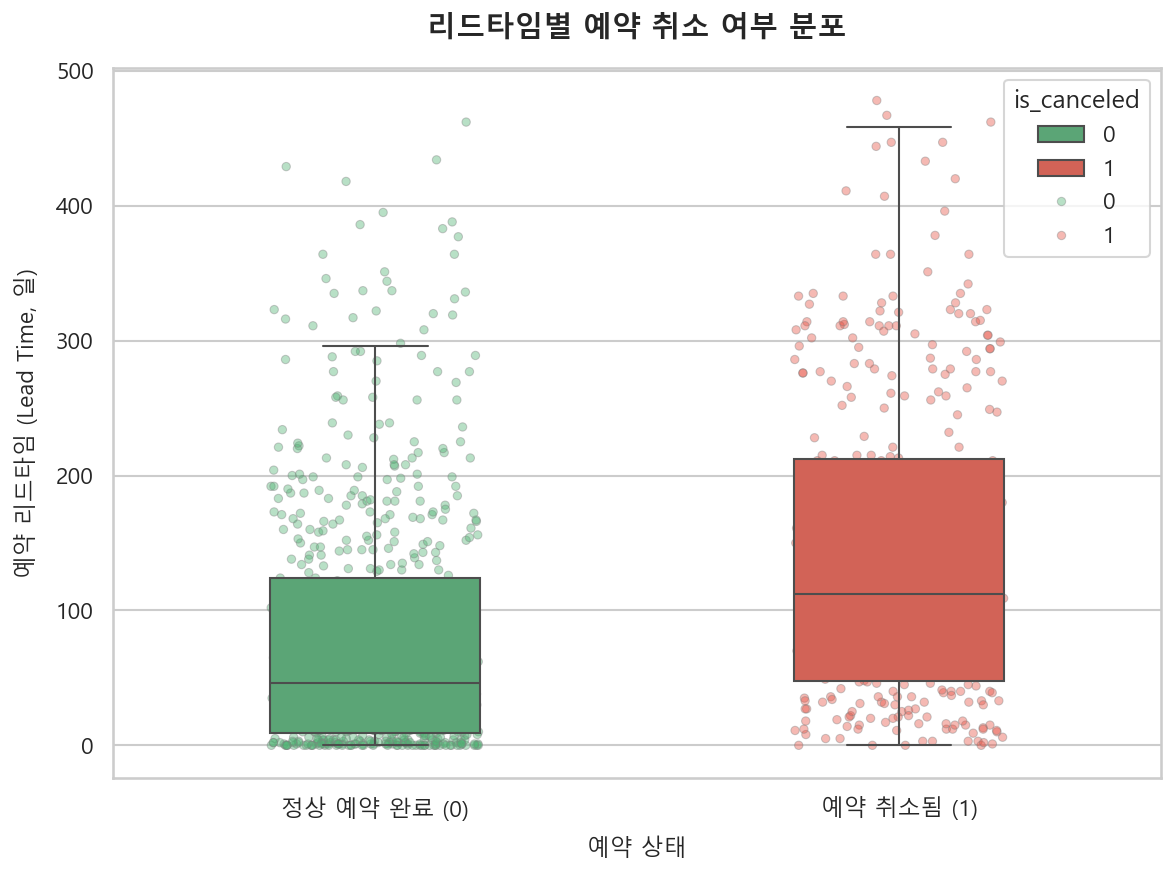

In [ ]:

try:
    df = pd.read_csv('prep_hotel_bookings.csv')
except Exception as e:
    df = pd.read_csv('hotel_bookings.csv')

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150


colors = {0: '#4eb272', 1: '#e65243'}
df_clean = df[(df['adr'] >= 0) & (df['adr'] < 400) & (df['lead_time'] <= 500)].copy()

# 단독 캔버스 생성 (가로 8인치, 세로 6인치)
plt.figure(figsize=(8, 6))

# 상자그림 (Box Plot)
sns.boxplot(
    data=df_clean, x='is_canceled', y='lead_time', palette=colors, hue='is_canceled',
    width=0.4, showfliers=False, zorder=2
)


np.random.seed(42)
df_sample = df_clean.sample(n=1000) if len(df_clean) > 1000 else df_clean
sns.stripplot(
    data=df_sample, x='is_canceled', y='lead_time', palette=colors, hue='is_canceled',
    size=4, alpha=0.4, jitter=0.2, linewidth=0.5, edgecolor='#7f7f7f', zorder=1
)

plt.title('리드타임별 예약 취소 여부 분포', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('예약 상태', fontsize=11, labelpad=8)
plt.ylabel('예약 리드타임 (Lead Time, 일)', fontsize=11, labelpad=8)
plt.xticks([0, 1], ['정상 예약 완료 (0)', '예약 취소됨 (1)'])

plt.tight_layout()
plt.savefig('lead_time_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()


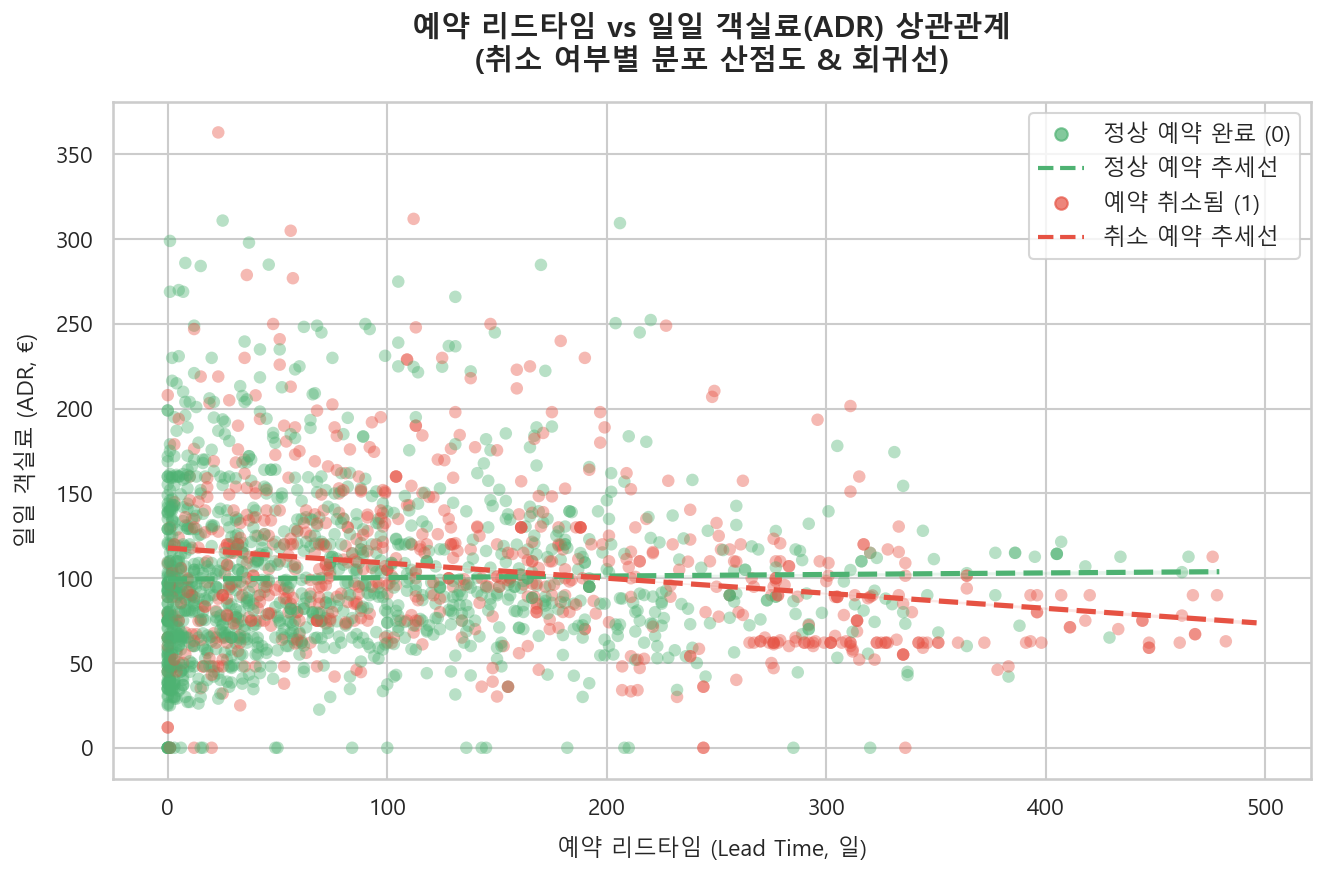

In [ ]:

try:
    df = pd.read_csv('prep_hotel_bookings.csv')
except Exception as e:
    df = pd.read_csv('hotel_bookings.csv')

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

colors = {0: '#4eb272', 1: '#e65243'}
labels_map = {0: '정상 예약 완료 (0)', 1: '예약 취소됨 (1)'}

df_clean = df[(df['adr'] >= 0) & (df['adr'] < 400) & (df['lead_time'] <= 500)].copy()

plt.figure(figsize=(9, 6))


df_scatter_sample = df_clean.sample(n=2000, random_state=42) if len(df_clean) > 2000 else df_clean
sns.scatterplot(
    data=df_scatter_sample, x='lead_time', y='adr', hue='is_canceled',
    palette=colors, alpha=0.4, edgecolor='none'
)


for cancel_val, color in colors.items():
    subset = df_clean[df_clean['is_canceled'] == cancel_val]
    sns.regplot(
        data=subset, x='lead_time', y='adr', scatter=False, color=color,
        line_kws={'linewidth': 2.5, 'linestyle': '--', 'label': f'{labels_map[cancel_val]} 추세선'}
    )

plt.title('예약 리드타임 vs 일일 객실료(ADR) 상관관계\n(취소 여부별 분포 산점도 & 회귀선)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('예약 리드타임 (Lead Time, 일)', fontsize=11, labelpad=8)
plt.ylabel('일일 객실료 (ADR, €)', fontsize=11, labelpad=8)

legend_elements = [
    mlines.Line2D([], [], color='#4eb272', marker='o', linestyle='None', markersize=6, alpha=0.7, label='정상 예약 완료 (0)'),
    mlines.Line2D([], [], color='#4eb272', linestyle='--', linewidth=2, label='정상 예약 추세선'),
    mlines.Line2D([], [], color='#e65243', marker='o', linestyle='None', markersize=6, alpha=0.7, label='예약 취소됨 (1)'),
    mlines.Line2D([], [], color='#e65243', linestyle='--', linewidth=2, label='취소 예약 추세선')
]
plt.legend(handles=legend_elements, frameon=True, facecolor='white', loc='upper right')

plt.tight_layout()
plt.savefig('lead_time_scatterplot.png', bbox_inches='tight', dpi=150)
plt.show()


### 2. deposit_type

In [ ]:
feature = 'deposit_type'

1) 교차표

In [ ]:
pd.crosstab(df[target], df[feature])

deposit_type,No Deposit,Non Refund,Refundable
is_canceled,,,
0,74526,93,126
1,29641,14480,36


In [ ]:
pd.crosstab(df[target], df[feature], normalize = 'columns')

deposit_type,No Deposit,Non Refund,Refundable
is_canceled,,,
0,0.715447,0.006382,0.777778
1,0.284553,0.993618,0.222222


2) 시각화

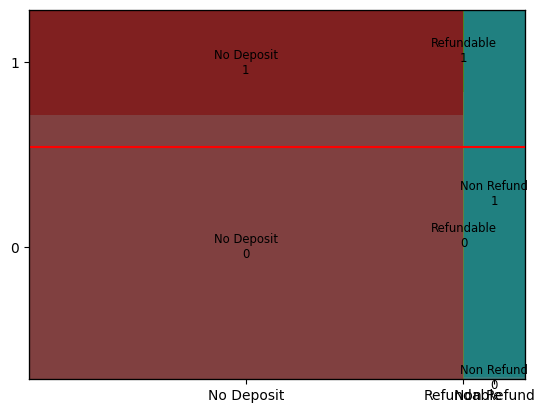

In [ ]:
mosaic(df, [feature, target], gap = 0)
plt.axhline(1- df[target].mean(), color = 'r')
plt.show()

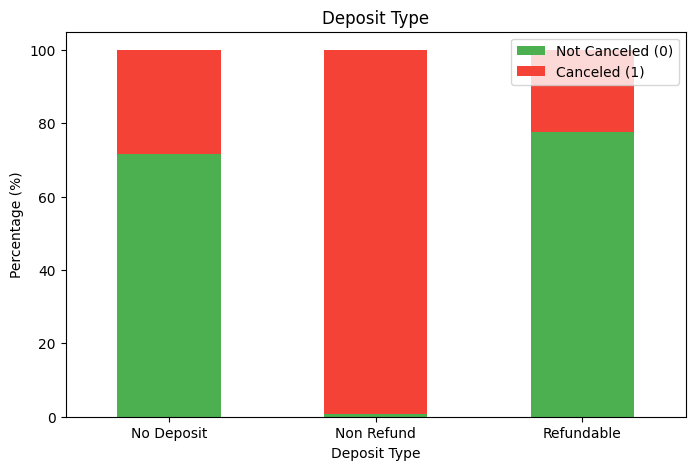

In [ ]:
# deposit_type별 is_canceled 비율 계산 (Cross Tabulation)
ct = pd.crosstab(df['deposit_type'], df['is_canceled'], normalize='index') * 100

# 시각화
ct.plot(kind='bar', stacked=True, color=['#4caf50', '#f44336'], figsize=(8, 5))
plt.title('Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Percentage (%)')
plt.legend(['Not Canceled (0)', 'Canceled (1)'], loc='upper right')
plt.xticks(rotation=0)
plt.show()

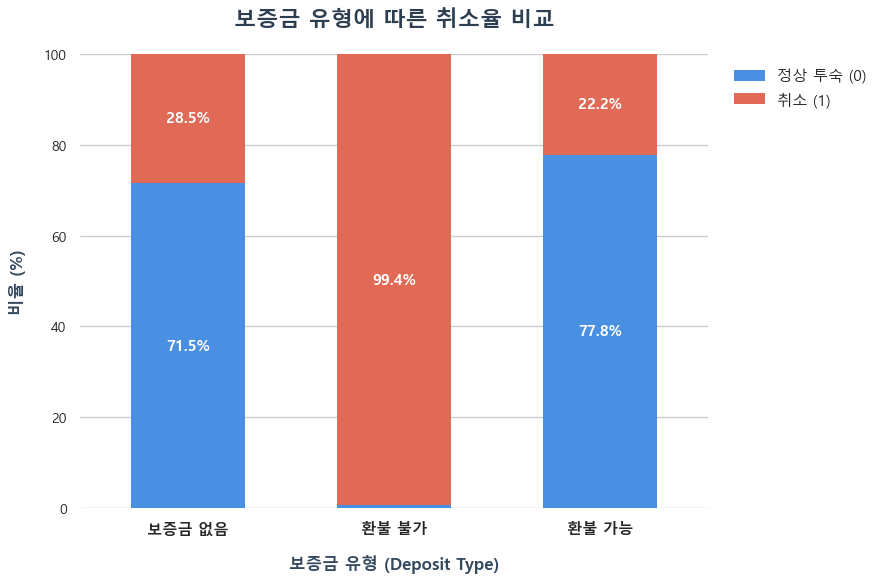

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 한글 설정 및 Seaborn 테마 적용
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. deposit_type별 is_canceled 비율 계산 (Cross Tabulation)
ct = pd.crosstab(df['deposit_type'], df['is_canceled'], normalize='index') * 100

# 한글화
ct.index = ct.index.map({
    'No Deposit': '보증금 없음',
    'Non Refund': '환불 불가',
    'Refundable': '환불 가능'
})

# 시각화
custom_colors = ['#4A90E2', '#E06A55']
fig, ax = plt.subplots(figsize=(9, 6))

ct.plot(
    kind='bar', 
    stacked=True, 
    color=custom_colors, 
    ax=ax, 
    width=0.55, 
    edgecolor='none'
)

for c in ax.containers:
    labels = [f'{val.get_height():.1f}%' if val.get_height() > 5 else '' for val in c]
    ax.bar_label(
        c, 
        labels=labels, 
        label_type='center', 
        fontsize=11, 
        fontweight='bold', 
        color='white'
    )


plt.title('보증금 유형에 따른 취소율 비교', fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel('보증금 유형 (Deposit Type)', fontsize=12, fontweight='bold', labelpad=12, color='#34495E')
plt.ylabel('비율 (%)', fontsize=12, fontweight='bold', labelpad=12, color='#34495E')

plt.legend(['정상 투숙 (0)', '취소 (1)'], loc='lower left', bbox_to_anchor=(1.02, 0.85), frameon=False)
plt.xticks(rotation=0, fontsize=11, fontweight='bold')
plt.yticks(fontsize=10)
plt.ylim(0, 100) # y축 범위를 100%로 고정

# 외곽선 제거
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


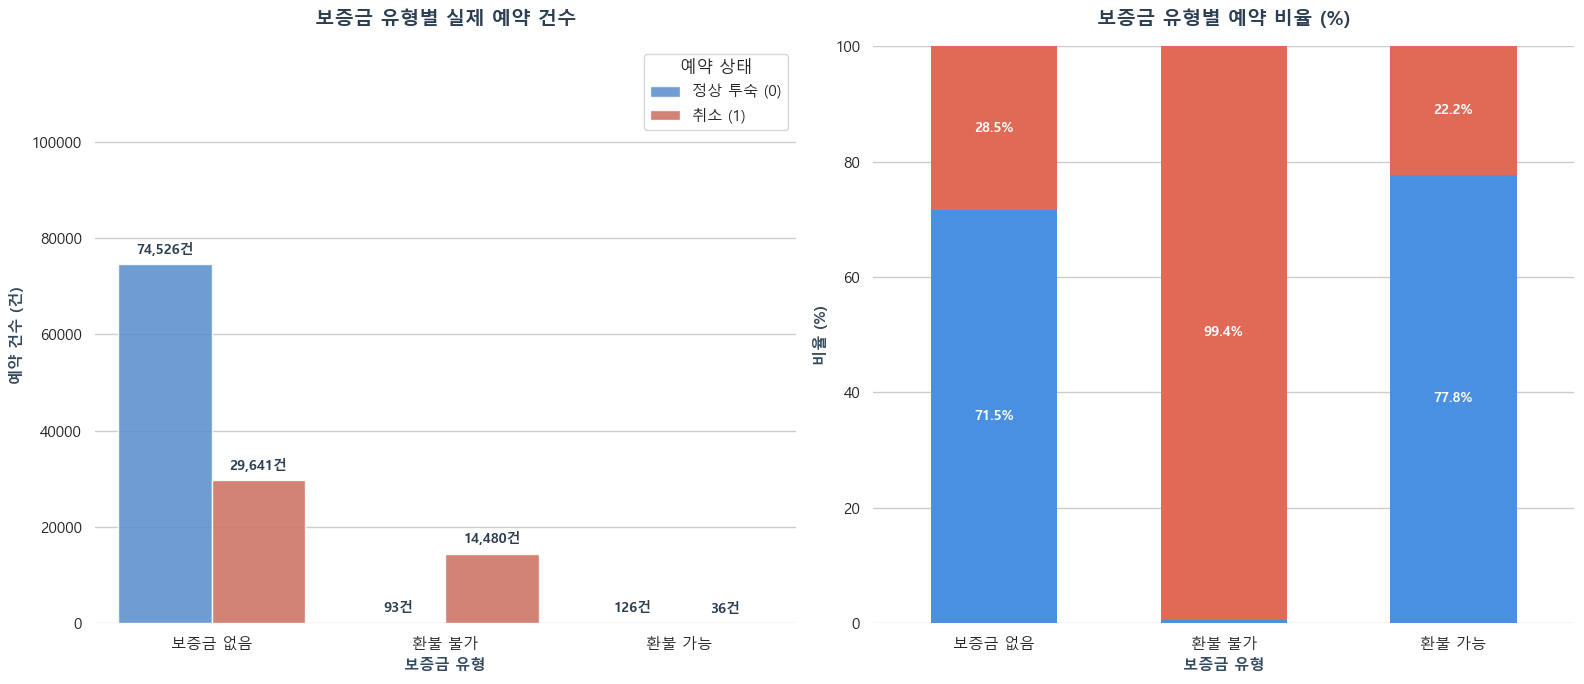

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 한글 설정 및 Seaborn 테마 적용
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 복사 및 한글 매핑
plot_df = df.copy()
plot_df['deposit_type_kor'] = plot_df['deposit_type'].map({
    'No Deposit': '보증금 없음',
    'Non Refund': '환불 불가',
    'Refundable': '환불 가능'
})
plot_df['is_canceled_kor'] = plot_df['is_canceled'].map({0: '정상 투숙 (0)', 1: '취소 (1)'})

# 3. 1행 2열 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
custom_colors = ['#4A90E2', '#E06A55']

# ----------------- [왼쪽 그래프: 실제 예약 건수] -----------------
ax1 = sns.countplot(
    x='deposit_type_kor',
    hue='is_canceled_kor',
    data=plot_df,
    order=['보증금 없음', '환불 불가', '환불 가능'],
    palette=custom_colors,
    ax=axes[0],
    alpha=0.9
)

# 막대 위에 건수 표시 라벨 추가 (천 단위 쉼표 적용)
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(
            f'{height:,.0f}건', 
            (p.get_x() + p.get_width() / 2., height + (plot_df['deposit_type_kor'].value_counts().max() * 0.015)), 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            fontweight='bold', 
            color='#2C3E50'
        )

ax1.set_title('보증금 유형별 실제 예약 건수', fontsize=14, fontweight='bold', pad=15, color='#2C3E50')
ax1.set_xlabel('보증금 유형', fontsize=11, fontweight='bold', color='#34495E')
ax1.set_ylabel('예약 건수 (건)', fontsize=11, fontweight='bold', color='#34495E')
ax1.legend(title='예약 상태', loc='upper right')
# 텍스트 라벨이 잘리지 않도록 y축 범위를 넉넉히 설정
ax1.set_ylim(0, plot_df['deposit_type_kor'].value_counts().max() * 1.15)


# ----------------- [오른쪽 그래프: 취소율 비율 (%)] -----------------
# deposit_type별 비율 크로스타블 계산 및 순서 정렬
ct = pd.crosstab(plot_df['deposit_type_kor'], plot_df['is_canceled_kor'], normalize='index') * 100
ct = ct.reindex(['보증금 없음', '환불 불가', '환불 가능'])

ct.plot(
    kind='bar', 
    stacked=True, 
    color=custom_colors, 
    ax=axes[1], 
    width=0.55, 
    edgecolor='none',
    rot=0 # x축 텍스트 눕지 않게 방지
)

# 막대 내부에 % 수치 추가 (소수점 첫째자리)
for c in axes[1].containers:
    labels = [f'{val.get_height():.1f}%' if val.get_height() > 5 else '' for val in c]
    axes[1].bar_label(
        c, 
        labels=labels, 
        label_type='center', 
        fontsize=10, 
        fontweight='bold', 
        color='white'
    )

axes[1].set_title('보증금 유형별 예약 비율 (%)', fontsize=14, fontweight='bold', pad=15, color='#2C3E50')
axes[1].set_xlabel('보증금 유형', fontsize=11, fontweight='bold', color='#34495E')
axes[1].set_ylabel('비율 (%)', fontsize=11, fontweight='bold', color='#34495E')
axes[1].legend().remove() # 왼쪽 범례와 겹치므로 제거
axes[1].set_ylim(0, 100)

# 공통 테두리 지우기
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


C:\Users\playdata2\AppData\Local\Temp\ipykernel_23204\599729109.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


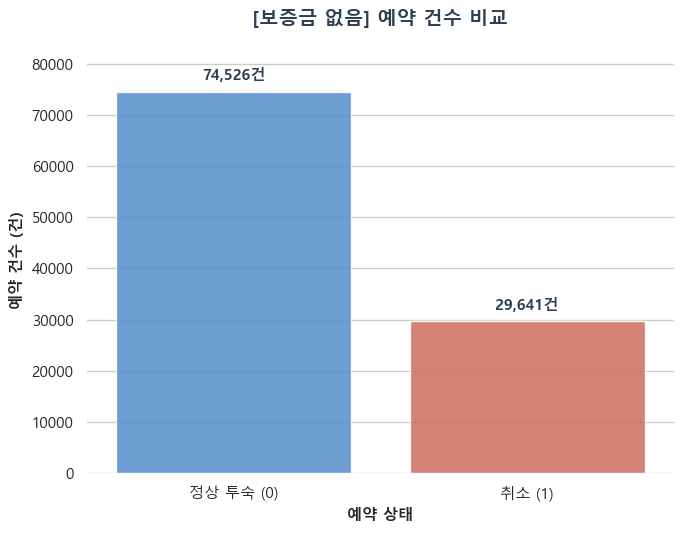

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 한글 설정 및 Seaborn 테마 적용
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. '보증금 없음 (No Deposit)' 데이터 필터링 및 매핑
sub_df = df[df['deposit_type'] == 'No Deposit'].copy()
sub_df['is_canceled_kor'] = sub_df['is_canceled'].map({0: '정상 투숙 (0)', 1: '취소 (1)'})

plt.figure(figsize=(7, 5.5))
custom_colors = ['#4A90E2', '#E06A55']

# 2. 그래프 그리기
ax = sns.countplot(
    x='is_canceled_kor',
    data=sub_df,
    order=['정상 투숙 (0)', '취소 (1)'],
    palette=custom_colors,
    alpha=0.9
)

# 3. 막대 위에 건수 표시 라벨 추가
max_count = sub_df['is_canceled_kor'].value_counts().max()
offset = max_count * 0.02

for p in ax.patches:
    height = p.get_height()
    val = height if not pd.isna(height) else 0
    ax.annotate(
        f'{val:,.0f}건', 
        (p.get_x() + p.get_width() / 2., val + offset), 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold', 
        color='#2C3E50'
    )

# 4. 레이블 및 서식 적용
plt.title('[보증금 없음] 예약 건수 비교', fontsize=14, fontweight='bold', pad=15, color='#2C3E50')
plt.xlabel('예약 상태', fontsize=11, fontweight='bold')
plt.ylabel('예약 건수 (건)', fontsize=11, fontweight='bold')
plt.ylim(0, max_count * 1.12)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()



C:\Users\playdata2\AppData\Local\Temp\ipykernel_23204\217299316.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


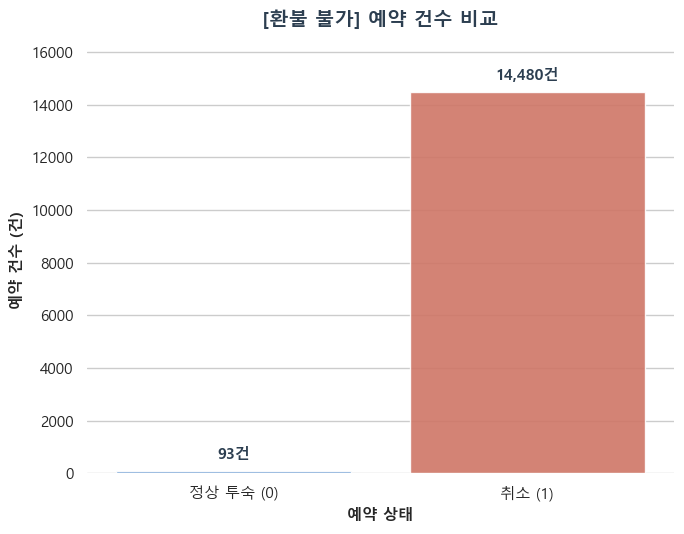

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 한글 설정 및 Seaborn 테마 적용
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. '환불 불가 (Non Refund)' 데이터 필터링 및 매핑
sub_df = df[df['deposit_type'] == 'Non Refund'].copy()
sub_df['is_canceled_kor'] = sub_df['is_canceled'].map({0: '정상 투숙 (0)', 1: '취소 (1)'})

plt.figure(figsize=(7, 5.5))
custom_colors = ['#4A90E2', '#E06A55']

# 2. 그래프 그리기
ax = sns.countplot(
    x='is_canceled_kor',
    data=sub_df,
    order=['정상 투숙 (0)', '취소 (1)'],
    palette=custom_colors,
    alpha=0.9
)

# 3. 막대 위에 건수 표시 라벨 추가
max_count = sub_df['is_canceled_kor'].value_counts().max()
offset = max_count * 0.02

for p in ax.patches:
    height = p.get_height()
    val = height if not pd.isna(height) else 0
    ax.annotate(
        f'{val:,.0f}건', 
        (p.get_x() + p.get_width() / 2., val + offset), 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold', 
        color='#2C3E50'
    )

# 4. 레이블 및 서식 적용
plt.title('[환불 불가] 예약 건수 비교', fontsize=14, fontweight='bold', pad=15, color='#2C3E50')
plt.xlabel('예약 상태', fontsize=11, fontweight='bold')
plt.ylabel('예약 건수 (건)', fontsize=11, fontweight='bold')
plt.ylim(0, max_count * 1.12)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


C:\Users\playdata2\AppData\Local\Temp\ipykernel_23204\289764254.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


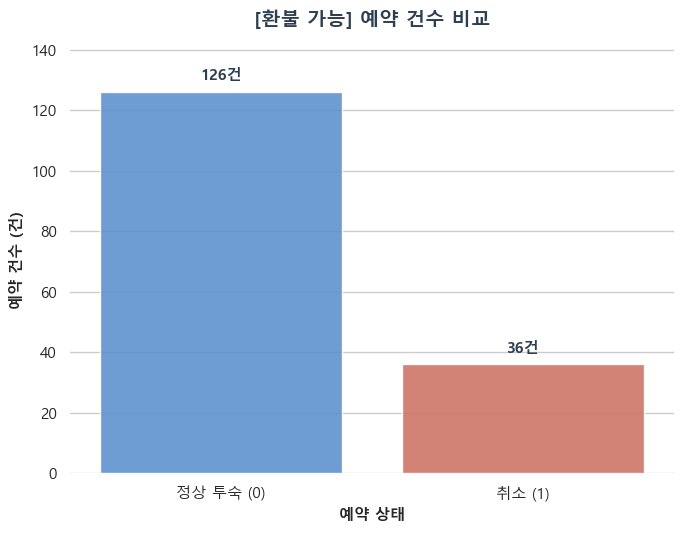

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 한글 설정 및 Seaborn 테마 적용
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. '환불 가능 (Refundable)' 데이터 필터링 및 매핑
sub_df = df[df['deposit_type'] == 'Refundable'].copy()
sub_df['is_canceled_kor'] = sub_df['is_canceled'].map({0: '정상 투숙 (0)', 1: '취소 (1)'})

plt.figure(figsize=(7, 5.5))
custom_colors = ['#4A90E2', '#E06A55']

# 2. 그래프 그리기
ax = sns.countplot(
    x='is_canceled_kor',
    data=sub_df,
    order=['정상 투숙 (0)', '취소 (1)'],
    palette=custom_colors,
    alpha=0.9
)

# 3. 막대 위에 건수 표시 라벨 추가
max_count = sub_df['is_canceled_kor'].value_counts().max()
offset = max_count * 0.02

for p in ax.patches:
    height = p.get_height()
    val = height if not pd.isna(height) else 0
    ax.annotate(
        f'{val:,.0f}건', 
        (p.get_x() + p.get_width() / 2., val + offset), 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold', 
        color='#2C3E50'
    )

# 4. 레이블 및 서식 적용
plt.title('[환불 가능] 예약 건수 비교', fontsize=14, fontweight='bold', pad=15, color='#2C3E50')
plt.xlabel('예약 상태', fontsize=11, fontweight='bold')
plt.ylabel('예약 건수 (건)', fontsize=11, fontweight='bold')
plt.ylim(0, max_count * 1.12)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import scipy.stats as spst

# 1. 교차표 집계 (Cross Tabulation)
table = pd.crosstab(df['is_canceled'], df['deposit_type'])
print('교차표\n', table)
print('-' * 100)

# 2. 카이제곱 검정 수행
result = spst.chi2_contingency(table)

print('카이제곱통계량 :', result[0])
print('p-value :', result[1])
print('자유도 :', result[2])
print('기대빈도 :\n', result[3])


교차표
 deposit_type  No Deposit  Non Refund  Refundable
is_canceled                                     
0                  74526          93         126
1                  29641       14480          36
----------------------------------------------------------------------------------------------------
카이제곱통계량 : 27548.334077761672
p-value : 0.0
자유도 : 2
기대빈도 :
 [[6.54821821e+04 9.16098035e+03 1.01837564e+02]
 [3.86848179e+04 5.41201965e+03 6.01624363e+01]]


### 3. deposit_type

- 카이제곱통계량: 27548,33
- P밸류: 0에 가까움
- 자유도: 2

=> 보증금 유형에 따른 취소율 차이는 통계적으로 유의미하다.

3) 수치화 : 카이제곱검정

In [ ]:
# 먼저 집계
table = pd.crosstab(df[target], df[feature])
print('교차표\n', table)
print('-' * 100)

# 카이제곱검정
result = spst.chi2_contingency(table)
print('카이제곱통계량 :', result[0])
print('p-value :', result[1])
print('자유도 :', result[2])
print('기대빈도 :\n',result[3])

교차표
 deposit_type  No Deposit  Non Refund  Refundable
is_canceled                                     
0                  74526          93         126
1                  29641       14480          36
----------------------------------------------------------------------------------------------------
카이제곱통계량 : 27548.334077761672
p-value : 0.0
자유도 : 2
기대빈도 :
 [[6.54821821e+04 9.16098035e+03 1.01837564e+02]
 [3.86848179e+04 5.41201965e+03 6.01624363e+01]]


### 4. adr

In [ ]:
feature = 'adr'

1) 교차표

In [ ]:
pd.crosstab(df[target], df[feature])

adr,-6.38,0.00,0.26,0.50,1.00,1.29,1.48,1.56,1.60,1.80,...,392.00,397.38,402.00,426.25,437.00,450.00,451.50,508.00,510.00,5400.00
is_canceled,,,,,,,,,,,,,,,,,,,,,
0,1,1735,1,0,12,1,0,2,1,1,...,1,1,1,1,0,0,1,1,1,0
1,0,203,0,1,3,0,1,0,0,0,...,1,0,0,0,1,1,0,0,0,1


In [ ]:
pd.crosstab(df[target], df[feature], normalize = 'columns')

adr,-6.38,0.00,0.26,0.50,1.00,1.29,1.48,1.56,1.60,1.80,...,392.00,397.38,402.00,426.25,437.00,450.00,451.50,508.00,510.00,5400.00
is_canceled,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.895253,1.0,0.0,0.8,1.0,0.0,1.0,1.0,1.0,...,0.5,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.0,0.104747,0.0,1.0,0.2,0.0,1.0,0.0,0.0,0.0,...,0.5,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
pd.crosstab(df[target], df[feature], normalize = 'all')

adr,-6.38,0.00,0.26,0.50,1.00,1.29,1.48,1.56,1.60,1.80,...,392.00,397.38,402.00,426.25,437.00,450.00,451.50,508.00,510.00,5400.00
is_canceled,,,,,,,,,,,,,,,,,,,,,
0,0.000008,0.014592,0.000008,0.000000,0.000101,0.000008,0.000000,0.000017,0.000008,0.000008,...,0.000008,0.000008,0.000008,0.000008,0.000000,0.000000,0.000008,0.000008,0.000008,0.000000
1,0.000000,0.001707,0.000000,0.000008,0.000025,0.000000,0.000008,0.000000,0.000000,0.000000,...,0.000008,0.000000,0.000000,0.000000,0.000008,0.000008,0.000000,0.000000,0.000000,0.000008


2) 시각화

In [ ]:
mosaic(df, [feature,target])
plt.axhline(1- df[target].mean(), color = 'r')
plt.show()

C:\Users\playdata2\AppData\Local\Temp\ipykernel_22764\1340131952.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\playdata2\AppData\Local\Temp\ipykernel_22764\1340131952.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['정상 체크인 (0)', '취소됨 (1)'])


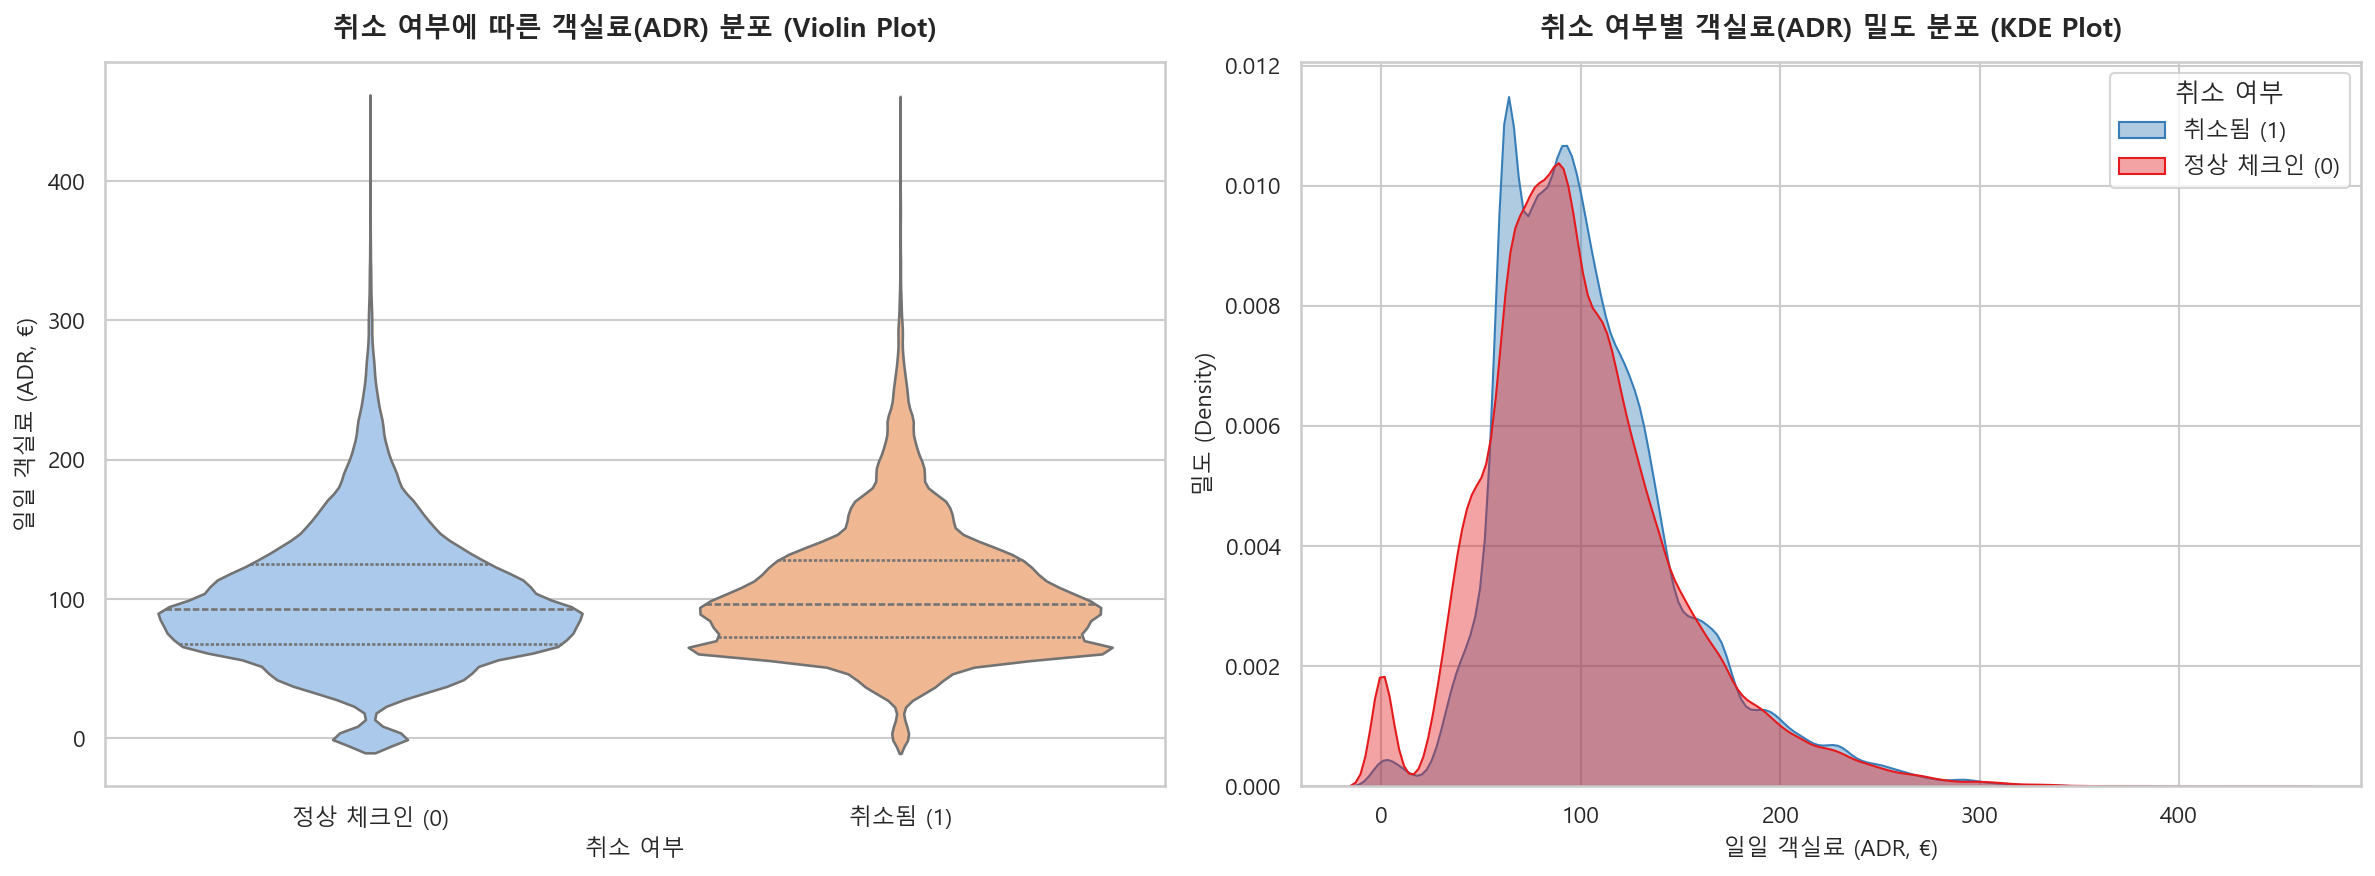

In [ ]:
# 1. 시각화의 가독성을 위해 극단적인 이상치 제거 (예: ADR 0 미만 및 500 초과 제거)
df_clean = df[(df['adr'] >= 0) & (df['adr'] < 500)].copy()

# 한글 폰트 설정 (환경에 맞게 선택, 윈도우 기준 Malgun Gothic)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 서브플롯 생성 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
-
sns.violinplot(
    data=df_clean, 
    x='is_canceled', 
    y='adr', 
    ax=axes[0], 
    palette='pastel',
    inner='quartile' # 사분위수 표시
)
axes[0].set_title('취소 여부에 따른 객실료(ADR) 분포 (Violin Plot)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('취소 여부', fontsize=11)
axes[0].set_ylabel('일일 객실료 (ADR, €)', fontsize=11)
axes[0].set_xticklabels(['정상 체크인 (0)', '취소됨 (1)'])

# --- [우측: KDE 밀도 곡선 플롯] 분포 겹쳐보기 ---
sns.kdeplot(
    data=df_clean, 
    x='adr', 
    hue='is_canceled', 
    fill=True, 
    common_norm=False, # 각 그룹별 독립적 비율로 시각화
    ax=axes[1], 
    palette='Set1', 
    alpha=0.4
)
axes[1].set_title('취소 여부별 객실료(ADR) 밀도 분포 (KDE Plot)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('일일 객실료 (ADR, €)', fontsize=11)
axes[1].set_ylabel('밀도 (Density)', fontsize=11)
axes[1].legend(title='취소 여부', labels=['취소됨 (1)', '정상 체크인 (0)'])

plt.tight_layout()
plt.show()


3) 수치화 : 카이제곱검정

In [ ]:
# 먼저 집계
table = pd.crosstab(df[target], df[feature])
print('교차표\n', table)
print('-' * 100)

# 카이제곱검정
result = spst.chi2_contingency(table)
print('카이제곱통계량 :', result[0])
print('p-value :', result[1])
print('자유도 :', result[2])
print('기대빈도 :\n',result[3])

교차표
 lead_time     0     1     2     3     4     5     6     7    8    9    ...  \
is_canceled                                                            ...   
0            5807  3076  1823  1621  1523  1339  1220  1138  903  766  ...   
1             416   319   211   181   173   206   202   172  222  219  ...   

lead_time    594  601  605  608  615  622  626  629  709  737  
is_canceled                                                    
0              0    0    0    0    0    0    0    0    1    1  
1             17   17   30   17   17   17   30   17    0    0  

[2 rows x 479 columns]
----------------------------------------------------------------------------------------------------
카이제곱통계량 : 18000.492651198336
p-value : 0.0
자유도 : 478
기대빈도 :
 [[3.91194543e+03 2.13418845e+03 1.27862719e+03 1.13278574e+03
  1.06615128e+03 9.71228617e+02 8.93907504e+02 8.23501287e+02
  7.07205304e+02 6.19197532e+02 6.11654009e+02 6.58801029e+02
  6.75145330e+02 5.14216834e+02 6.03481859e+02 5.26789

4) 파악된 내용을 기술해 봅시다.

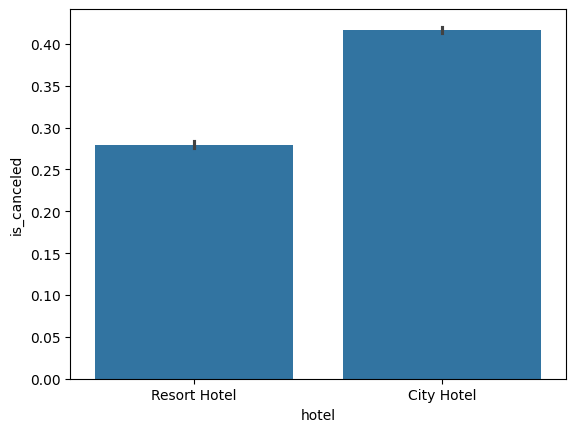

In [ ]:
var='agent'

sns.barplot(x=var, y= target, data=df, order = ['Resort Hotel', 'City Hotel'])  # order: 원하는 순서대로
plt.show()

C:\Users\playdata2\AppData\Local\Temp\ipykernel_23204\284143439.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


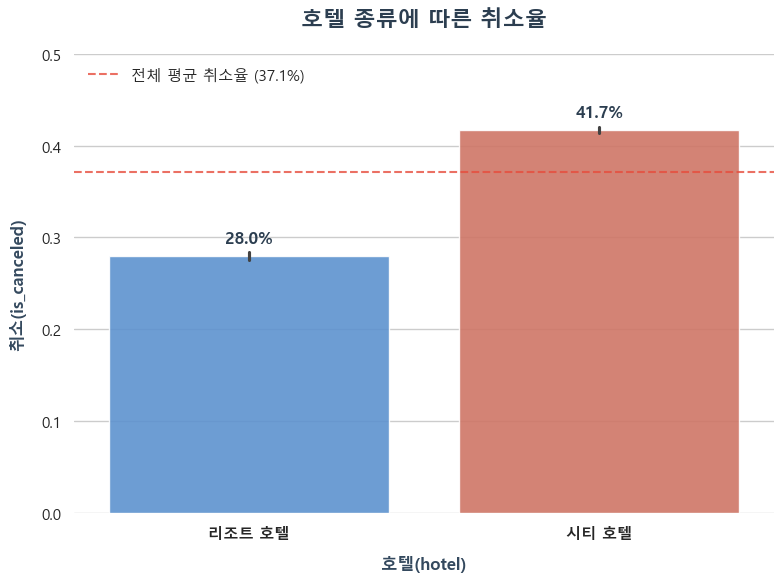

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우용 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

# ----------------- 이후 그래프 그리는 코드 -----------------
plt.figure(figsize=(8, 6))

var = 'hotel'
target = 'is_canceled'
custom_palette = ['#4A90E2', '#E06A55']

ax = sns.barplot(
    x=var, 
    y=target, 
    data=df, 
    order=['Resort Hotel', 'City Hotel'],
    palette=custom_palette, 
    alpha=0.9
)

total_mean = df[target].mean()
plt.axhline(
    total_mean, 
    color='#E74C3C', 
    linestyle='--', 
    linewidth=1.5, 
    alpha=0.8,
    label=f'전체 평균 취소율 ({total_mean:.1%})'
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1%}', 
        (p.get_x() + p.get_width() / 2., height + 0.01), 
        ha='center', 
        va='bottom', 
        fontsize=12, 
        fontweight='bold',
        color='#2C3E50'
    )

# x축 한글화
plt.xticks([0, 1], ['리조트 호텔', '시티 호텔'], fontsize=11, fontweight='bold')

plt.title('호텔 종류에 따른 취소율', fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel('호텔(hotel)', fontsize=12, fontweight='bold', labelpad=10, color='#34495E')
plt.ylabel('취소(is_canceled)', fontsize=12, fontweight='bold', labelpad=10, color='#34495E')
plt.ylim(0, 0.5) 
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


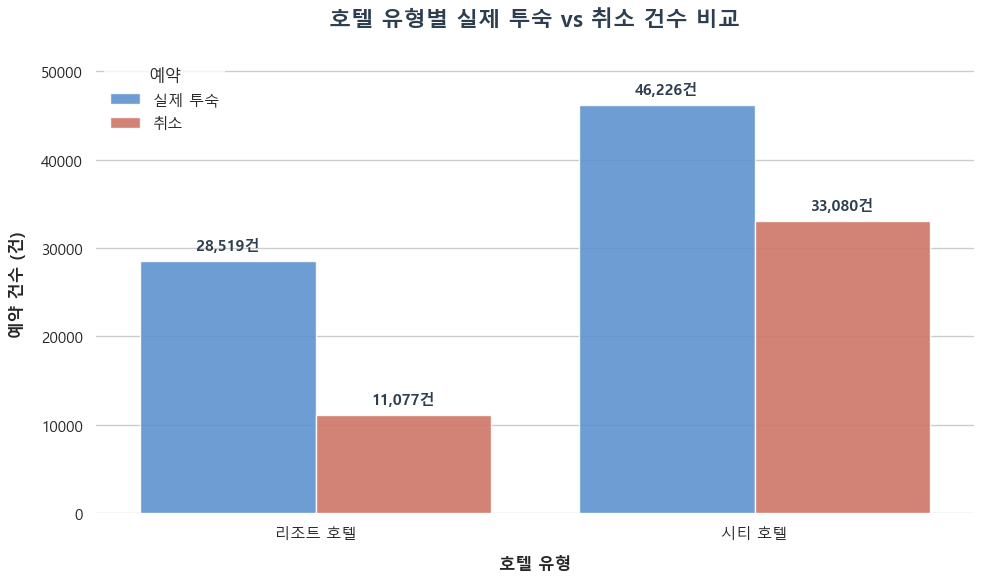

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. Seaborn 테마 설정
sns.set_theme(style="whitegrid", font="Malgun Gothic")
plt.figure(figsize=(10, 6))

# 데이터 프레임 복사 및 한글 매핑
plot_df = df.copy()
plot_df['hotel_kor'] = plot_df['hotel'].map({'Resort Hotel': '리조트 호텔', 'City Hotel': '시티 호텔'})
plot_df['is_canceled_kor'] = plot_df['is_canceled'].map({0: '실제 투숙', 1: '취소'})


ax = sns.countplot(
    x='hotel_kor',
    hue='is_canceled_kor',
    data=plot_df,
    order=['리조트 호텔', '시티 호텔'],
    palette=['#4A90E2', '#E06A55'],
    alpha=0.9
)

for p in ax.patches:
    height = p.get_height()
    if height > 0: # 빈 데이터 방지
        ax.annotate(
            f'{height:,.0f}건', 
            (p.get_x() + p.get_width() / 2., height + 800), # 막대 끝에서 살짝 위에 표시
            ha='center', 
            va='bottom', 
            fontsize=11, 
            fontweight='bold',
            color='#2C3E50'
        )

# 4. 차트 레이블 정리
plt.title('호텔 유형별 실제 투숙 vs 취소 건수 비교', fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel('호텔 유형', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('예약 건수 (건)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(0, 52000) # 숫자 표시를 위해 y축 위쪽 여유 공간 확보
plt.legend(title='예약', loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# 불필요한 차트 외곽선 제거
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


In [ ]:
# 먼저 집계
table = pd.crosstab(df1[target], df1[feature])
print('교차표\n', table)
print('-' * 100)

# 카이제곱검정
result = spst.chi2_contingency(table)
print('카이제곱통계량', result[0])
print('p-value', result[1])
print('자유도 :', result[2])
print('기대빈도\n',result[3])

교차표
 MaritalStatus  Divorced  Married
Attrition                       
0                   241      479
1                    23       69
----------------------------------------------------------------------------------------------------
카이제곱통계량 2.296463502781439
p-value 0.1296689376509814
자유도 : 1
기대빈도
 [[234.08866995 485.91133005]
 [ 29.91133005  62.08866995]]
